Business Problem 

A travel company offers various holiday packages to customers through sales representatives and marketing campaigns. Despite significant efforts in customer outreach, not all customers choose to purchase the offered travel packages.

The company wants to understand the factors that influence customer purchase decisions and identify the characteristics of customers who are more likely to buy a travel package. By analyzing customer demographics, income levels, travel preferences, and sales interaction details, the company aims to improve its marketing strategies, optimize sales efforts, and increase package conversion rates.

Importing the Libraries

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [79]:
## Loading the data
df = pd.read_csv('Travel_Customer_Behaviour.csv')
print(f"Loaded Dataset : {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Dataset : 4888 rows, 20 columns


In [80]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [81]:
df.tail()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0
4887,204887,1,36.0,Self Enquiry,1,14.0,Salaried,Male,4,4.0,Basic,4.0,Unmarried,3.0,1,3,1,2.0,Executive,24041.0


In [82]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [84]:
## Checking for duplicates
df.duplicated().sum()

0

In [85]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')

In [86]:
df.describe(include = 'all')

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4863,4888.000000,4637.000000,4888,4888,4888.000000,4843.000000,4888,4862.000000,4888,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4888,4655.000000
unique,NaN,NaN,NaN,2,NaN,NaN,4,2,NaN,NaN,5,NaN,4,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,Self Enquiry,NaN,NaN,Salaried,Male,NaN,NaN,Basic,NaN,Married,NaN,NaN,NaN,NaN,NaN,Executive,NaN
freq,NaN,NaN,NaN,3444,NaN,NaN,2368,2916,NaN,NaN,1842,NaN,2340,NaN,NaN,NaN,NaN,NaN,1842,NaN
mean,202443.500000,0.188216,37.622265,NaN,1.654255,15.490835,NaN,NaN,2.905074,3.708445,NaN,3.581037,NaN,3.236521,0.290917,3.078151,0.620295,1.187267,NaN,23619.853491
std,1411.188388,0.390925,9.316387,NaN,0.916583,8.519643,NaN,NaN,0.724891,1.002509,NaN,0.798009,NaN,1.849019,0.454232,1.365792,0.485363,0.857861,NaN,5380.698361
min,200000.000000,0.000000,18.000000,NaN,1.000000,5.000000,NaN,NaN,1.000000,1.000000,NaN,3.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,NaN,1000.000000
25%,201221.750000,0.000000,31.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,3.000000,NaN,2.000000,0.000000,2.000000,0.000000,1.000000,NaN,20346.000000
50%,202443.500000,0.000000,36.000000,NaN,1.000000,13.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,3.000000,1.000000,1.000000,NaN,22347.000000
75%,203665.250000,0.000000,44.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,4.000000,1.000000,4.000000,1.000000,2.000000,NaN,25571.000000


In [87]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,4888,NaN,NaN,NaN,202444,1411.19,200000,201222,202444,203665,204887
ProdTaken,4888,NaN,NaN,NaN,0.188216,0.390925,0,0,0,0,1
Age,4662,NaN,NaN,NaN,37.6223,9.31639,18,31,36,44,61
TypeofContact,4863,2,Self Enquiry,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,4888,NaN,NaN,NaN,1.65426,0.916583,1,1,1,3,3
DurationOfPitch,4637,NaN,NaN,NaN,15.4908,8.51964,5,9,13,20,127
Occupation,4888,4,Salaried,2368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,4888,2,Male,2916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfPersonVisiting,4888,NaN,NaN,NaN,2.90507,0.724891,1,2,3,3,5
NumberOfFollowups,4843,NaN,NaN,NaN,3.70845,1.00251,1,3,4,4,6


In [88]:
#Checking for Missing Values
df.isnull().sum()


CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [89]:
#Filling the missing values
df['Age'] = df.groupby('Designation')['Age'].transform(lambda x:x.fillna(x.median()))
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0], inplace = True)
df['DurationOfPitch'] = df.groupby('ProductPitched')['DurationOfPitch'].transform(lambda x:x.fillna(x.median()))
df['NumberOfFollowups'] = df.groupby('ProductPitched')['NumberOfFollowups'].transform(lambda x:x.fillna(x.median()))
df['PreferredPropertyStar'] = df.groupby('ProductPitched')['PreferredPropertyStar'].transform(lambda x:x.fillna(x.median()))
df['NumberOfTrips'] = df.groupby(['Occupation','Passport'])['NumberOfTrips'].transform(lambda x:x.fillna(x.median()))
df['NumberOfChildrenVisiting'] = df.groupby('MaritalStatus')['NumberOfChildrenVisiting'].transform(lambda x:x.fillna(x.median()))
df['MonthlyIncome'] = df.groupby('Designation')['MonthlyIncome'].transform(lambda x:x.fillna(x.median()))

In [90]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

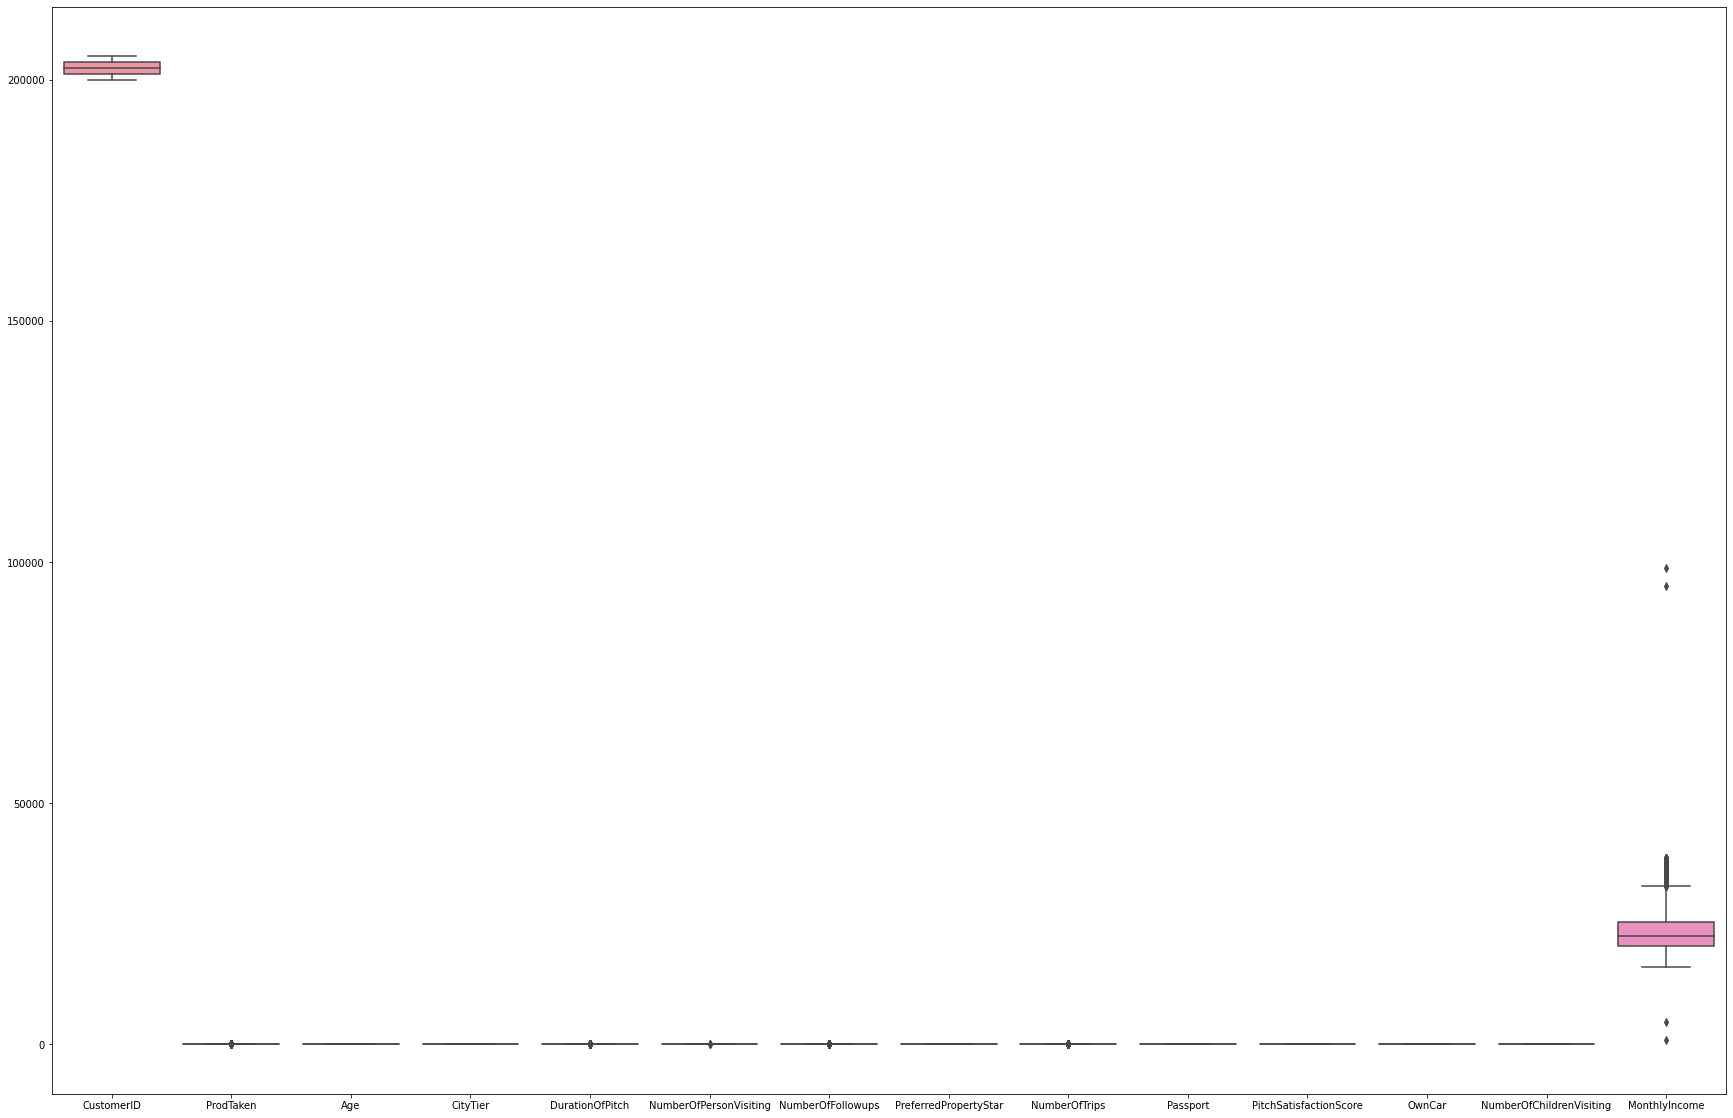

In [91]:
#Checking for outliers
plt.figure(figsize = (30,20))
sns.boxplot(data = df)
plt.show()

Outlier Treatment

<AxesSubplot:>

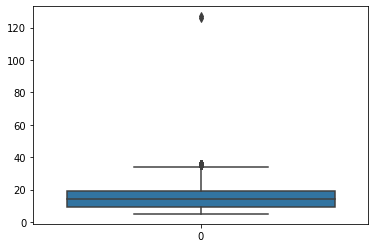

In [92]:
sns.boxplot(data = 
            df['DurationOfPitch'])

In [93]:
#IQR
Q3 = df['DurationOfPitch'].quantile(0.75)
Q1 = df['DurationOfPitch'].quantile(0.25)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
#Identify Outliers
df[(df['DurationOfPitch']>upper_limit)| (df['DurationOfPitch']<lower_limit)]
#Capping
df['DurationOfPitch'] = df['DurationOfPitch'].clip(upper_limit,lower_limit)

<AxesSubplot:>

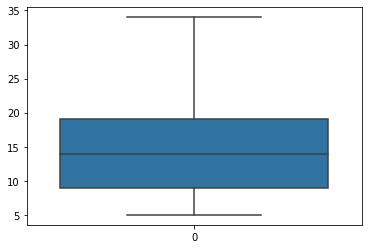

In [94]:
sns.boxplot(data = 
            df['DurationOfPitch'])

<AxesSubplot:>

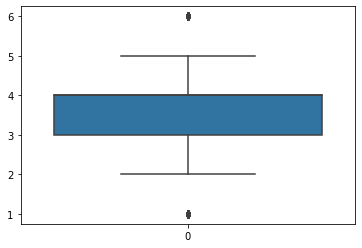

In [95]:
sns.boxplot(data = df['NumberOfFollowups'])

<AxesSubplot:>

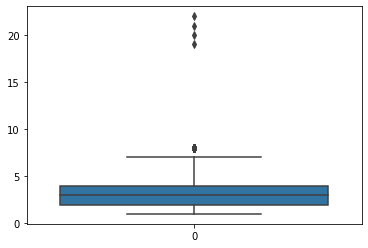

In [96]:
sns.boxplot(data = df['NumberOfTrips'])

In [97]:
df['NumberOfTrips'].max()

22.0

In [98]:
columns = ['NumberOfTrips']
for col in columns:
    Q3 = df[col].quantile(0.75)
    Q1 = df[col].quantile(0.25)
    IQR = Q3 - Q1

    lower_limit = Q3 - 1.5 * IQR
    upper_limit = Q1 + 1.5 * IQR
    df[col] = df[col].clip(upper_limit,lower_limit)

<AxesSubplot:>

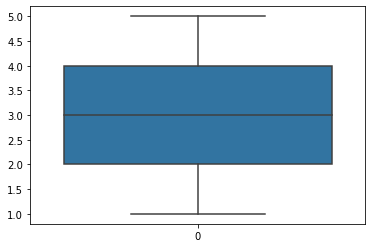

In [99]:
sns.boxplot(data = df['NumberOfTrips'])

<AxesSubplot:>

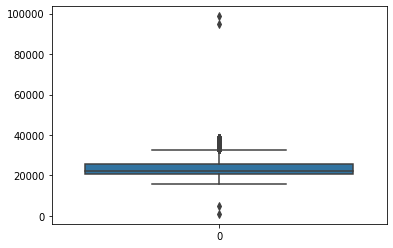

In [100]:
sns.boxplot(data = df['MonthlyIncome'])

In [101]:
#Percentile
upper_limit = df['MonthlyIncome'].quantile(0.99)
lower_limit = df['MonthlyIncome'].quantile(0.1)

df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper_limit,lower_limit)

<AxesSubplot:>

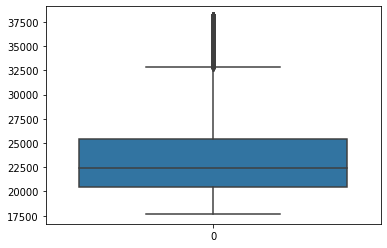

In [102]:
sns.boxplot(data = df['MonthlyIncome'])

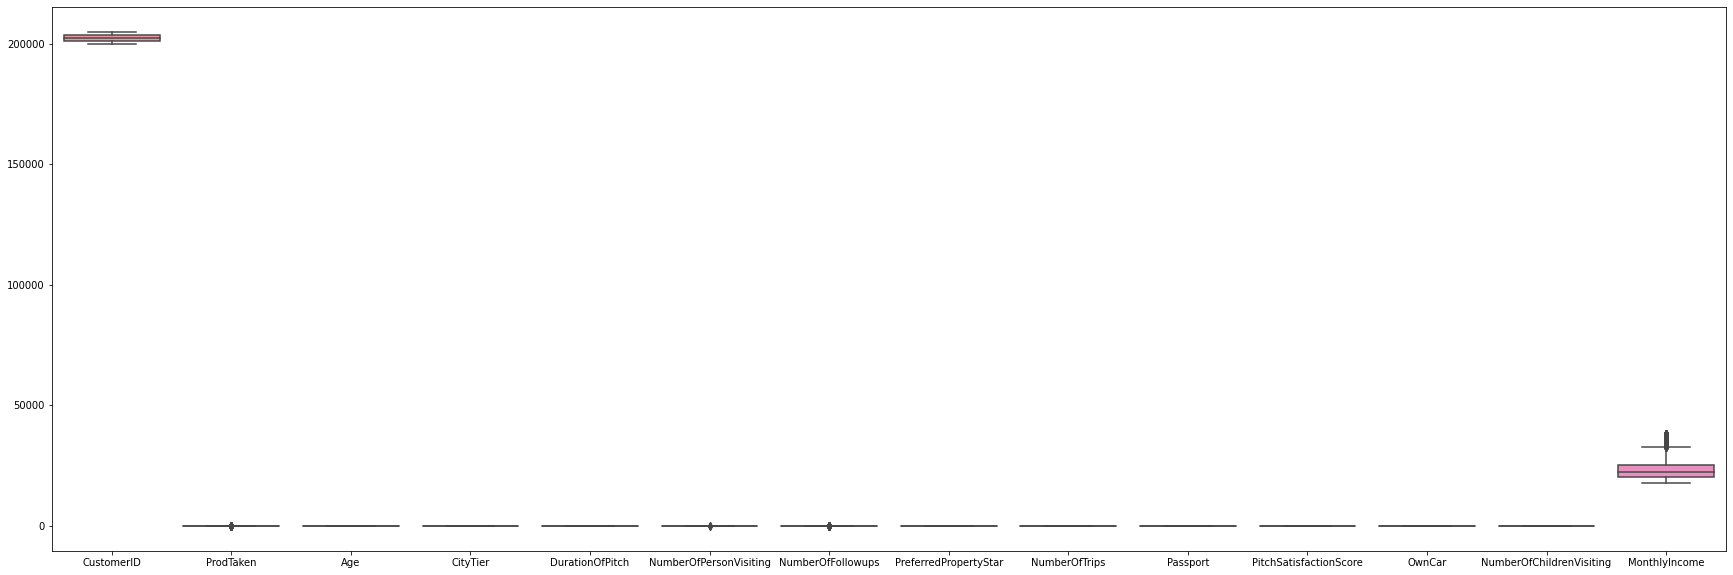

In [103]:
plt.figure(figsize = (30,10))
sns.boxplot(data = df)
plt.show()

In [104]:
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [105]:
#Fixing Data types
df['NumberOfFollowups'] = df['NumberOfFollowups'].astype(int)
df['PreferredPropertyStar'] = df['PreferredPropertyStar'].astype(int)
df['NumberOfTrips'] = df['NumberOfTrips'].astype(int)
df['NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].astype(int)

In [106]:
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups             int32
ProductPitched               object
PreferredPropertyStar         int32
MaritalStatus                object
NumberOfTrips                 int32
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting      int32
Designation                  object
MonthlyIncome               float64
dtype: object

UNIVARIATE ANALYSIS

#Define Numerical and Categorical columns

In [107]:
numerical_cols = df.select_dtypes(include=['int64','float64'])
categorical_cols = df.select_dtypes(include=['object'])

Univariate Analysis on Numerical columns

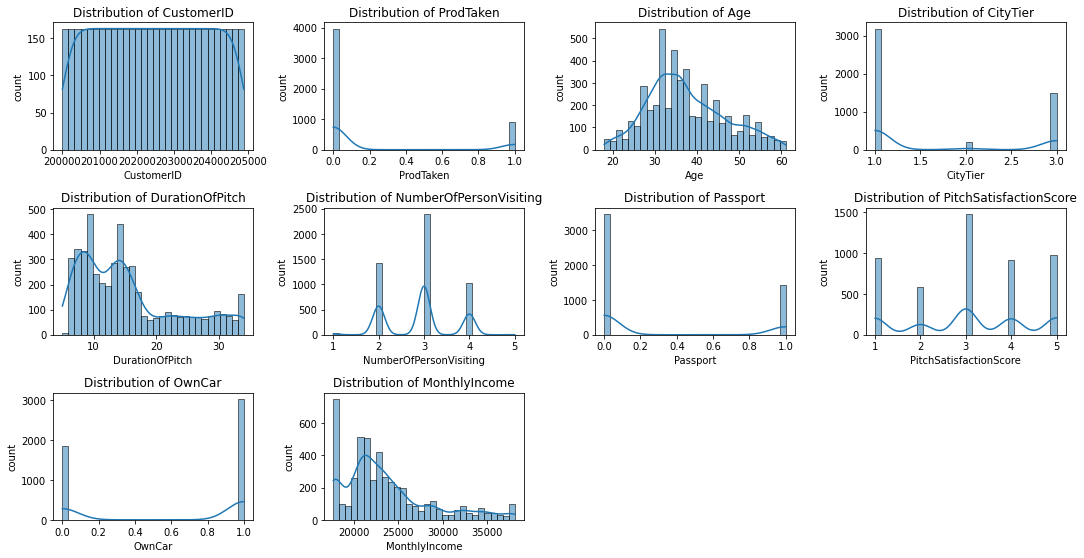

In [108]:
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('count')
plt.tight_layout()
plt.show()

In [109]:
#Checking Skewness
for col in numerical_cols:
    
    print(f"{col}.{df[col].skew()}")

CustomerID.0.0
ProdTaken.1.595763483620565
Age.0.44178278726654313
CityTier.0.7365306801370617
DurationOfPitch.0.9318704497243739
NumberOfPersonVisiting.0.02981670373673057
Passport.0.9209798312180442
PitchSatisfactionScore.-0.12772555980000866
OwnCar.-0.4958919323352372
MonthlyIncome.1.1310883075790927


In [110]:
#Checking Kurtosis - 
for col in numerical_cols:
    print(f"{col}: {df[col].kurt()}")

CustomerID: -1.2
ProdTaken: 0.5466846126000937
Age: -0.34855658761679287
CityTier: -1.4033052057270814
DurationOfPitch: -0.1802357506712733
NumberOfPersonVisiting: -0.7774673392607441
Passport: -1.1522677859771089
PitchSatisfactionScore: -1.1028697709043274
OwnCar: -1.7548093660610462
MonthlyIncome: 0.7506490973533868


In [111]:
## 1.0 = balanced kurtosis
## 2.<0 = flat distribution, fewer outliers, safe.
## 3.>0 = more outliers
## from the above, MonthlyIncome = 0.7642....  

In [112]:
#Check Variability.
for col in numerical_cols:
    mean = df[col].mean()
    std = df[col].std()
    print(f"{col}:{std/mean}")

CustomerID:0.006970776478796589
ProdTaken:2.076999285673094
Age:0.24445268295795758
CityTier:0.5540761377716936
DurationOfPitch:0.5171670149797242
NumberOfPersonVisiting:0.24952572031831952
Passport:1.5613810713293128
PitchSatisfactionScore:0.44370530140447023
OwnCar:0.7824720195917143
MonthlyIncome:0.2113773343886713


In [113]:
print(type(numerical_cols))

<class 'pandas.core.frame.DataFrame'>


Univariate Analysis on Categorical Columns

In [114]:
for col in categorical_cols:
    print(f"{col} : {df[col].value_counts()}")

TypeofContact : Self Enquiry       3469
Company Invited    1419
Name: TypeofContact, dtype: int64
Occupation : Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: Occupation, dtype: int64
Gender : Male      2916
Female    1972
Name: Gender, dtype: int64
ProductPitched : Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: ProductPitched, dtype: int64
MaritalStatus : Married      2340
Divorced      950
Single        916
Unmarried     682
Name: MaritalStatus, dtype: int64
Designation : Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: Designation, dtype: int64


In [115]:
#Percentage Distribution
for col in categorical_cols:
    print(df[col].value_counts(normalize = True)*100)

Self Enquiry       70.969722
Company Invited    29.030278
Name: TypeofContact, dtype: float64
Salaried          48.445172
Small Business    42.635025
Large Business     8.878887
Free Lancer        0.040917
Name: Occupation, dtype: float64
Male      59.656301
Female    40.343699
Name: Gender, dtype: float64
Basic           37.684124
Deluxe          35.433715
Standard        15.180033
Super Deluxe     6.996727
King             4.705401
Name: ProductPitched, dtype: float64
Married      47.872340
Divorced     19.435352
Single       18.739771
Unmarried    13.952537
Name: MaritalStatus, dtype: float64
Executive         37.684124
Manager           35.433715
Senior Manager    15.180033
AVP                6.996727
VP                 4.705401
Name: Designation, dtype: float64


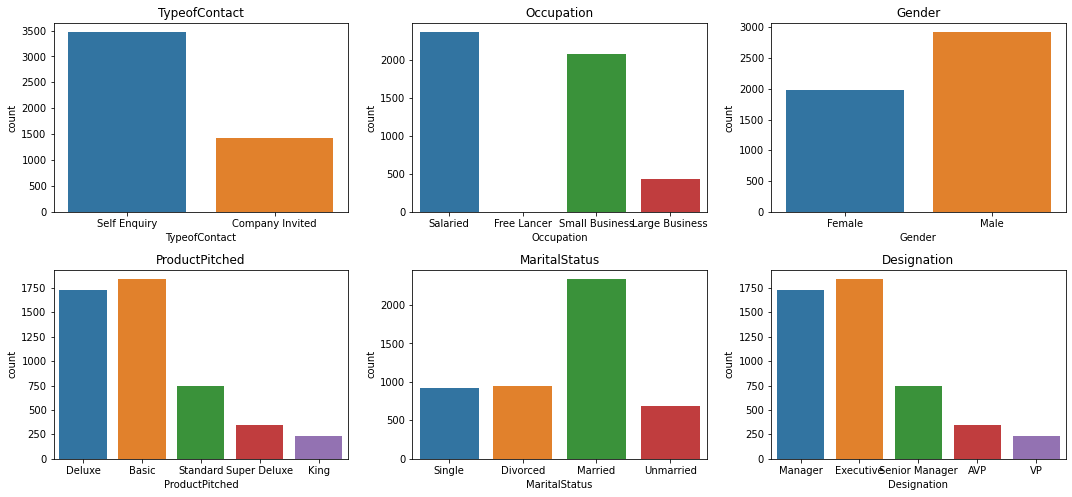

In [116]:
plt.figure(figsize = (15,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1) #3,3 if needed
    sns.countplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS

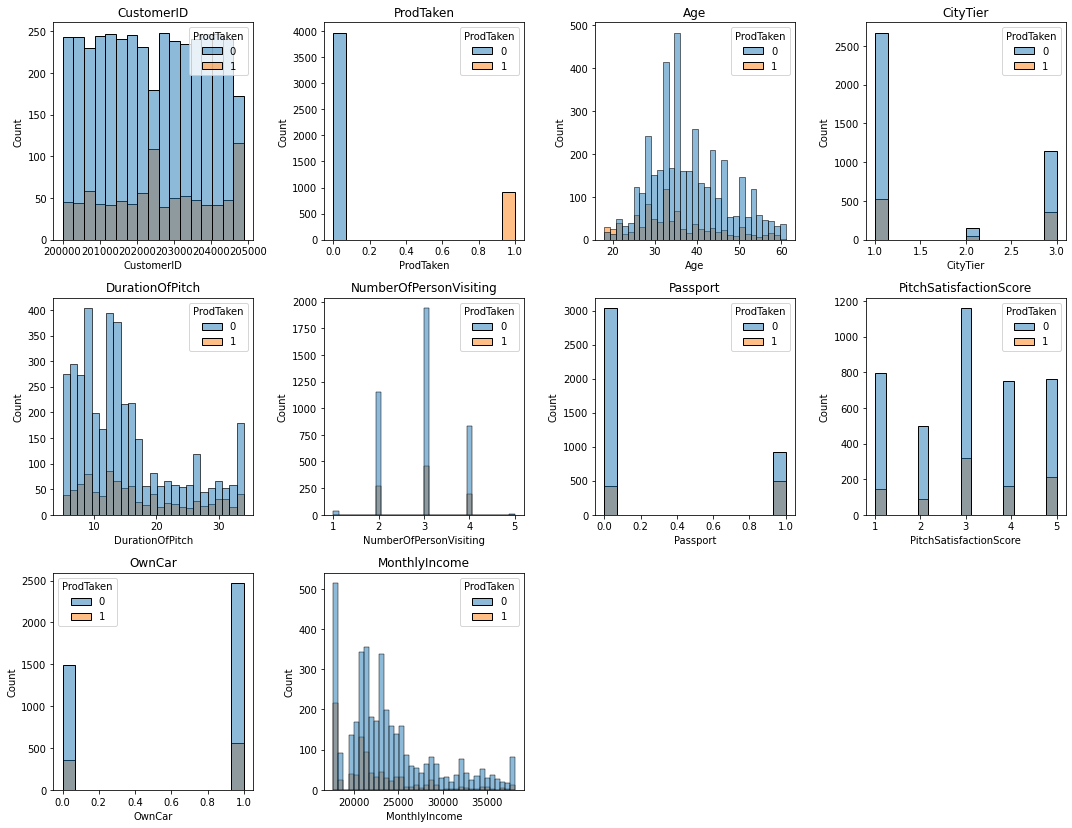

In [117]:
plt.figure(figsize = (15,15))

for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(data = df, x = col, hue = 'ProdTaken')
    plt.title(col)

plt.tight_layout()
plt.show()

In [118]:
for col in numerical_cols:
    print(df.groupby('ProdTaken')[col].median())

ProdTaken
0    202407.5
1    202443.5
Name: CustomerID, dtype: float64
ProdTaken
0    0
1    1
Name: ProdTaken, dtype: int64
ProdTaken
0    36.0
1    33.0
Name: Age, dtype: float64
ProdTaken
0    1
1    1
Name: CityTier, dtype: int64
ProdTaken
0    13.0
1    15.0
Name: DurationOfPitch, dtype: float64
ProdTaken
0    3
1    3
Name: NumberOfPersonVisiting, dtype: int64
ProdTaken
0    0
1    1
Name: Passport, dtype: int64
ProdTaken
0    3
1    3
Name: PitchSatisfactionScore, dtype: int64
ProdTaken
0    1
1    1
Name: OwnCar, dtype: int64
ProdTaken
0    22861.0
1    21136.5
Name: MonthlyIncome, dtype: float64


In [119]:
## Based on the Median Difference
## Age, MonthlyIncome are moderately influencing the ProdTaken.
## DurationOfPitch is highly Influencing the ProdTaken, people with high Duration of Pitch are likely to buy the Product.

In [120]:
#Checking IQR Spread - variability
for col in numerical_cols:
    print(f"\n {col}")
    q1 = df.groupby('ProdTaken')[col].quantile(0.25)
    q3 = df.groupby('ProdTaken')[col].quantile(0.75)
    iqr = q3 - q1
    result = pd.DataFrame({
        'Q1' : q1,
        'Q3' : q3,
        'IQR' : iqr
    })
    print(result)


 CustomerID
                  Q1         Q3     IQR
ProdTaken                              
0          201186.50  203629.50  2443.0
1          201393.75  203835.25  2441.5

 ProdTaken
            Q1   Q3  IQR
ProdTaken               
0          0.0  0.0  0.0
1          1.0  1.0  0.0

 Age
             Q1    Q3   IQR
ProdTaken                  
0          32.0  44.0  12.0
1          28.0  41.0  13.0

 CityTier
            Q1   Q3  IQR
ProdTaken               
0          1.0  3.0  2.0
1          1.0  3.0  2.0

 DurationOfPitch
             Q1    Q3   IQR
ProdTaken                  
0           9.0  18.0   9.0
1          10.0  23.0  13.0

 NumberOfPersonVisiting
            Q1   Q3  IQR
ProdTaken               
0          2.0  3.0  1.0
1          2.0  3.0  1.0

 Passport
            Q1   Q3  IQR
ProdTaken               
0          0.0  0.0  0.0
1          0.0  1.0  1.0

 PitchSatisfactionScore
            Q1   Q3  IQR
ProdTaken               
0          2.0  4.0  2.0
1          2.0  4.0 

In [121]:
## From IQR Spread
## DurationofPitch showing Strong positive Influence on ProdTaken.
## MonthlyIncome, Age, PrefferedPropertyStar are moderatley influencing ProdTaken.

In [122]:
## From Median difference and IQR spread 
## MonthlyIncome, Age, DurationOfPitch are slightly overlapping. 
## Remaining columns are highly overlapping 


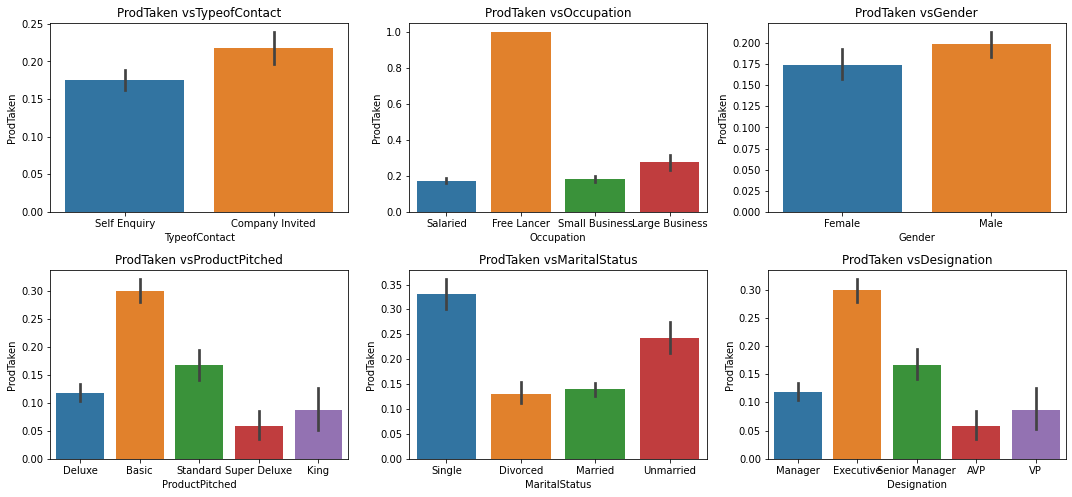

In [123]:
plt.figure(figsize=(15,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.barplot(x = col, y = 'ProdTaken', data = df)
    plt.title(f"ProdTaken vs{col}")
plt.tight_layout()
plt.show()

In [124]:
for col in categorical_cols:   
    print(df.groupby(col)['ProdTaken'].mean().sort_values(ascending=False))

TypeofContact
Company Invited    0.218464
Self Enquiry       0.175843
Name: ProdTaken, dtype: float64
Occupation
Free Lancer       1.000000
Large Business    0.276498
Small Business    0.184261
Salaried          0.174831
Name: ProdTaken, dtype: float64
Gender
Male      0.198217
Female    0.173428
Name: ProdTaken, dtype: float64
ProductPitched
Basic           0.299674
Standard        0.167116
Deluxe          0.117783
King            0.086957
Super Deluxe    0.058480
Name: ProdTaken, dtype: float64
MaritalStatus
Single       0.331878
Unmarried    0.243402
Married      0.139316
Divorced     0.130526
Name: ProdTaken, dtype: float64
Designation
Executive         0.299674
Senior Manager    0.167116
Manager           0.117783
VP                0.086957
AVP               0.058480
Name: ProdTaken, dtype: float64


In [125]:
for col in categorical_cols:
    print(df[col].value_counts(normalize=True)*100)

Self Enquiry       70.969722
Company Invited    29.030278
Name: TypeofContact, dtype: float64
Salaried          48.445172
Small Business    42.635025
Large Business     8.878887
Free Lancer        0.040917
Name: Occupation, dtype: float64
Male      59.656301
Female    40.343699
Name: Gender, dtype: float64
Basic           37.684124
Deluxe          35.433715
Standard        15.180033
Super Deluxe     6.996727
King             4.705401
Name: ProductPitched, dtype: float64
Married      47.872340
Divorced     19.435352
Single       18.739771
Unmarried    13.952537
Name: MaritalStatus, dtype: float64
Executive         37.684124
Manager           35.433715
Senior Manager    15.180033
AVP                6.996727
VP                 4.705401
Name: Designation, dtype: float64


In [126]:
pd.crosstab(df['ProductPitched'], df['Designation'])

Designation,AVP,Executive,Manager,Senior Manager,VP
ProductPitched,,,,,
Basic,0,1842,0,0,0
Deluxe,0,0,1732,0,0
King,0,0,0,0,230
Standard,0,0,0,742,0
Super Deluxe,342,0,0,0,0


ProductPitched and Designation exhibit a strong one-to-one relationship, indicating redundancy for predictive modeling. Therefore, one of these variables may be removed during future model development to avoid multicollinearity. However, both variables are retained in the current analysis to preserve business context and support exploratory insights.

In [127]:
import re

df.columns = [re.sub(r'(?<!^)([A-Z])', r'_\1', col).lower() for col in df.columns]

MULTIVARIATE ANALYSIS

In [128]:
#Correlation on numerical independent variables
df[['age', 'monthly_income', 'duration_of_pitch', 'prod_taken']].corr()


,age,monthly_income,duration_of_pitch,prod_taken
age,1.000000,0.487794,-0.011367,-0.145218
monthly_income,0.487794,1.000000,0.003429,-0.129572
duration_of_pitch,-0.011367,0.003429,1.000000,0.081667
prod_taken,-0.145218,-0.129572,0.081667,1.000000


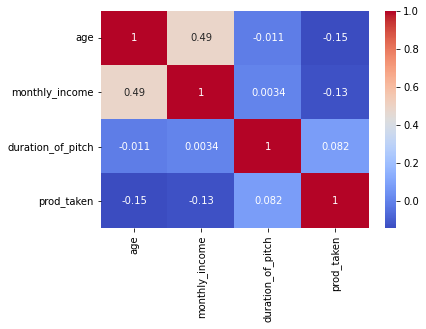

In [129]:
#heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','monthly_income','duration_of_pitch','prod_taken']].corr(),annot = True, cmap = 'coolwarm')
plt.show()

In [130]:
#multivariate analysis on categorical columns
pd.crosstab(
    [df['typeof_contact'],
     df['product_pitched'],
     df['marital_status']],
    df['prod_taken'],
    normalize='index'
)

prod_taken                                             0         1
typeof_contact  product_pitched marital_status                    
Company Invited Basic           Divorced        0.794872  0.205128
                                Married         0.708333  0.291667
                                Single          0.464516  0.535484
                                Unmarried       0.418605  0.581395
                Deluxe          Divorced        0.919192  0.080808
                                Married         0.939850  0.060150
                                Single          0.750000  0.250000
                                Unmarried       0.750000  0.250000
                King            Divorced        1.000000  0.000000
                                Married         1.000000  0.000000
                                Single          1.000000  0.000000
                Standard        Divorced        0.909091  0.090909
                                Married         0.872340  0.127660
                                Single          0.687500  0.312500
                                Unmarried       0.828125  0.171875
                Super Deluxe    Divorced        1.000000  0.000000
                                Married         0.846154  0.153846
                                Single          0.750000  0.250000
                                Unmarried       0.000000  1.000000
Self Enquiry    Basic           Divorced        0.826772  0.173228
                                Married         0.795139  0.204861
                                Single          0.587079  0.412921
                                Unmarried       0.650000  0.350000
                Deluxe          Divorced        0.898734  0.101266
                                Married         0.911263  0.088737
                                Single          0.818792  0.181208
                                Unmarried       0.849315  0.150685
                King            Divorced        0.863636  0.136364
                                Married         0.938776  0.061224
                                Single          0.800000  0.200000
                Standard        Divorced        0.775510  0.224490
                                Married         0.846154  0.153846
                                Single          0.823529  0.176471
                                Unmarried       0.811321  0.188679
                Super Deluxe    Divorced        1.000000  0.000000
                                Married         1.000000  0.000000
                                Single          0.931034  0.068966
                                Unmarried       1.000000  0.000000

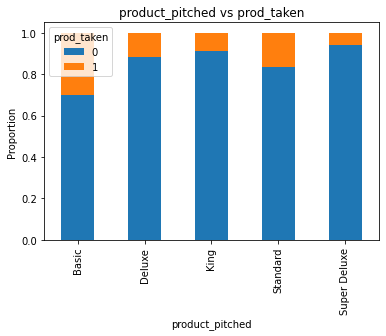

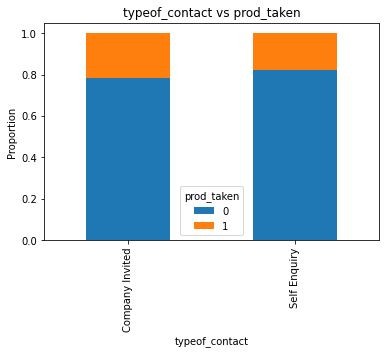

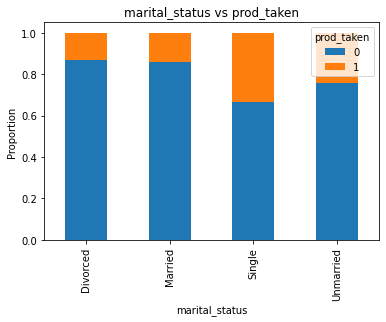

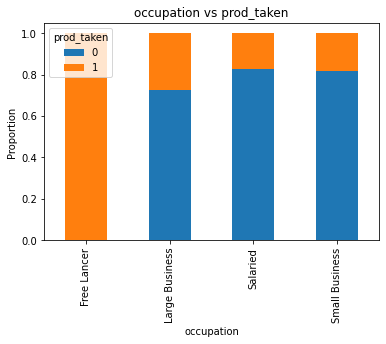

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

independent_var = ['product_pitched','typeof_contact', 'marital_status','occupation']

for col in independent_var:
    pd.crosstab(df[col], df['prod_taken'], normalize='index') \
        .plot(kind='bar', stacked=True, figsize=(6,4))
    
    plt.title(f"{col} vs prod_taken")
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.legend(title='prod_taken')
    plt.show()


Based on univariate, bivariate, and multivariate analysis, Age and MonthlyIncome showed comparatively higher association among numerical features, while TypeofContact and ProductPitched demonstrated stronger influence on package conversion behavior among categorical variables.


In [132]:
from scipy.stats import ttest_ind

numerical_test_cols = ['age','monthly_income','duration_of_pitch']

for col in numerical_test_cols:

    group0 = df[df['prod_taken']==0][col]
    group1 = df[df['prod_taken']==1][col]

    stat,p = ttest_ind(group0,group1,nan_policy='omit')

    print(f"\n{col}")
    print(f"P-value = {p}")

    if p < 0.05:
        print("Significant relationship")
    else:
        print("No significant relationship")


age
P-value = 1.8965666495223887e-24
Significant relationship

monthly_income
P-value = 9.4581399775689e-20
Significant relationship

duration_of_pitch
P-value = 1.0794471791119828e-08
Significant relationship


In [133]:
from scipy.stats import chi2_contingency

cat_cols = [
    'typeof_contact',
    'product_pitched',
    'marital_status',
    'occupation'
]

for col in cat_cols:

    table = pd.crosstab(df[col],df['prod_taken'])

    chi2,p,dof,expected = chi2_contingency(table)

    print(f"\n{col}")
    print(f"P-value = {p}")

    if p < 0.05:
        print("Significant association")
    else:
        print("No significant association")


typeof_contact
P-value = 0.0006265194822329932
Significant association

product_pitched
P-value = 2.42359680098374e-55
Significant association

marital_status
P-value = 6.072002571578408e-42
Significant association

occupation
P-value = 2.2330028260738476e-07
Significant association


Hypothesis testing revealed statistically significant relationships between package purchase behavior and all tested variables. Among numerical features, Age and MonthlyIncome demonstrated the strongest statistical association with package conversion. Among categorical features, ProductPitched and MaritalStatus exhibited the strongest associations, followed by Occupation and TypeofContact.

In [134]:
# Run this before encoding cells
df_dashboard = df.copy()

# Save cleaned data for Tableau
df_dashboard.to_csv('Travel_Cleaned.csv', index=False)

print("CSV exported successfully!")
print(df_dashboard.shape)
print(df_dashboard.columns.tolist())

CSV exported successfully!
(4888, 20)
['customer_i_d', 'prod_taken', 'age', 'typeof_contact', 'city_tier', 'duration_of_pitch', 'occupation', 'gender', 'number_of_person_visiting', 'number_of_followups', 'product_pitched', 'preferred_property_star', 'marital_status', 'number_of_trips', 'passport', 'pitch_satisfaction_score', 'own_car', 'number_of_children_visiting', 'designation', 'monthly_income']


Encoding on categorical columns

In [135]:
print(df['prod_taken'].value_counts())
print(df['prod_taken'].value_counts(normalize=True) * 100)

0    3968
1     920
Name: prod_taken, dtype: int64
0    81.178396
1    18.821604
Name: prod_taken, dtype: float64


In [136]:
print(df.groupby('prod_taken')[['age', 'monthly_income', 'duration_of_pitch']].median())

             age  monthly_income  duration_of_pitch
prod_taken                                         
0           36.0         22861.0               13.0
1           33.0         21136.5               15.0


In [137]:
df.to_csv('Travel_Cleaned.csv', index=False)